# Cat An? No, his name is Hubert.
<img alt="image.png" src="data\img.png"/>
Our first project revolves around analyzing the "strongest" starting locations for the game of *CATAN*. Settlers of Catan, or just Catan, is a traditional German-style strategy board game, where you assume the role of settlers setting out to conquer new land. The majority of the game revolves around expanding your *settlements* and *roads*, which require certain resources like ore and wheat to build. We will be mostly ignoring the game's mechanics beyond the initial draft where each of the 4 players decides where to place their starting set of 2 settlements and 2 roads. Settlements can only go at the intersections between the resource tiles, which we represent as nodes, and the roads can only go between tiles, which we represent as edges. Our goal is to determine where we should place our starting buildings in order to maximize our chances of winning.

Here are some useful links for learning Catan (you don't need to know anything beyond the Setup phase, but it might help to understand how the game plays to better interpret the different centralities):
- Official Rulebook - https://www.catan.com/sites/default/files/2021-06/catan_base_rules_2020_200707.pdf
- Official Intro to Catan - https://www.youtube.com/watch?v=6OF32Eq5DZo
- Detailed Intro to Catan - https://www.youtube.com/watch?v=8Yj0Y3GKE40

As the first step of this project, we will use the inherent network structure of the gameboard in order to determine what is the most advantageous settlement location based on which resource tiles it is the intersection of. While, I am sure it is possible to run something akin a Monte Carlo simulation, or train an ML model in order to learn a mapping between the initial board state and game outcomes, we will approach this problem through a more analytical complex systems perspective - using Network Science. Below you can find the code for generating, and visualizing the actual network, which you can safely ignore, as long as you understand how the DEMO section works, you should be able to work through the rest with enough Googling and Clauding.

**Your tasks before the next meeting**
- explore different network centrality measures (degree, closeness, eigenvector, etc.)
- screenshot the resulting board/network for each measure
- write 1-2 sentences on the intuitive explanation on what features of the board these measures are capturing
- stretch goal: come up with some (preferably optimal) algorithm on how each player in the draft should behave (i.e. where should they place their starting buildings). Note that the draft order is as follows: 1->2->3->4->4->3->2->1.

As a reminder, the *Networks* book by Mark Newman is the best resource for learning the foundations of this field, and Chapters {1, *3*, 6, 7.1} are particularly relevant to this project (Ch. 3 is tangential and will be more relevant in our future projects). Additionally, we will be using the NetworkX Python library for most of our network shenanigans, so look for its documentation to figure out how to calculate the different centralities. To that end, I *heavily* encourage you to work through https://networkx.org/documentation/stable/tutorial.html in addition to the rest of this project.
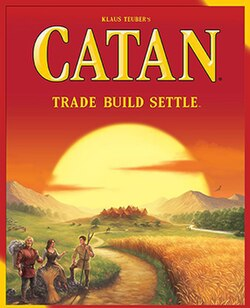

## Catan Board/Network Generator

In [2]:
### Imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
"""
Catan Board Network Generator
==============================

Models a standard Settlers of Catan board as a NetworkX graph, where:
  - **Nodes** (54) are intersection points where settlements can be placed
  - **Edges** (72) are road segments connecting adjacent intersections

Indexing convention
-------------------
Both tiles and nodes are indexed **left-to-right, top-to-bottom** (reading
order), so you can locate any element by scanning the board the way you'd
read a page.

Tiles (19 hexes, rows of 3-4-5-4-3):

           0   1   2
         3   4   5   6
       7   8   9  10  11
        12  13  14  15
          16  17  18

Nodes (54 intersections, rows of 3-4-4-5-5-6-6-5-5-4-4-3):

           0   1   2
          3   4   5   6
          7   8   9  10
        11  12  13  14  15
        16  17  18  19  20
       21  22  23  24  25  26
       27  28  29  30  31  32
        33  34  35  36  37
        38  39  40  41  42
         43  44  45  46
         47  48  49  50
           51  52  53

Each node stores two attributes:
  - 'pos':         (x, y) cartesian coordinates for plotting
  - 'hex_indices': set of tile indices that the node touches (1, 2, or 3 tiles)

Geometry
--------
The board uses **pointy-top** hexagons (vertex at 12 o'clock, flat edges on
left and right), matching the physical Catan game. Hex size defaults to 1.0,
meaning each hex edge has length 1 and the distance between adjacent
intersection nodes is also 1.

Usage
-----
    >>> G, hex_centers = generate_catan_board()
    >>> draw_board(G, hex_centers)                        # plain board
    >>> draw_board(G, hex_centers, tile_data=my_tiles)    # with resources
"""

# ============================================================================
# Board generation
# ============================================================================

def hex_corners(cx, cy, size=1.0):
    """
    Compute the 6 corner positions of a single pointy-top hexagon.

    Corners start at the top (12 o'clock) and proceed clockwise:
      k=0 → top, k=1 → upper-right, k=2 → lower-right,
      k=3 → bottom, k=4 → lower-left, k=5 → upper-left

    Parameters
    ----------
    cx, cy : float — center of the hexagon
    size   : float — distance from center to any vertex (hex "radius")

    Returns
    -------
    list of 6 (x, y) tuples
    """
    return [
        (cx + size * np.cos(np.pi / 2 + np.pi / 3 * k),
         cy + size * np.sin(np.pi / 2 + np.pi / 3 * k))
        for k in range(6)
    ]


def generate_catan_board(size=1.0):
    """
    Build the Catan intersection graph.

    Algorithm:
      1. Lay out 19 hex centers in a 3-4-5-4-3 grid
      2. Compute all 6 corners per hex (19 × 6 = 114 points)
      3. Deduplicate shared corners → 54 unique nodes
      4. Connect nodes that are exactly one hex-edge apart → 72 edges
      5. Re-number nodes in reading order (left-to-right, top-to-bottom)

    Parameters
    ----------
    size : float — hex edge length / vertex radius (default 1.0)

    Returns
    -------
    G : nx.Graph
        54-node, 72-edge graph.
        Node attributes:
          - 'pos' : (x, y) cartesian coordinates
          - 'hex_indices' : set of tile indices this node touches
    hex_centers : list of (x, y)
        Cartesian centers of the 19 hex tiles, also in reading order.
    """
    # --- Step 1: Hex center positions ---
    # Standard Catan has rows of 3, 4, 5, 4, 3 tiles.
    # For pointy-top hexes the spacing is:
    #   horizontal (within a row) = sqrt(3) * size
    #   vertical (between rows)   = 1.5 * size
    row_counts = [3, 4, 5, 4, 3]    # NOTE: in the future we can extend how different board configurations alter the game outcome
    dx = np.sqrt(3) * size  # horizontal gap between hex centers
    dy = 1.5 * size         # vertical gap between hex rows

    hex_centers = []
    y_top = (len(row_counts) - 1) / 2 * dy  # y-coordinate of the top row
    for row_idx, count in enumerate(row_counts):
        y = y_top - row_idx * dy
        x_start = -(count - 1) / 2 * dx  # center each row horizontally
        for col in range(count):
            hex_centers.append((x_start + col * dx, y))

    # --- Step 2 & 3: Corners → deduplicated nodes ---
    # Adjacent hexes share 2 corners each, so many of the 114 raw corners
    # overlap. We merge any two points closer than `eps` into one node,
    # and track which tiles each node borders.
    eps = 1e-6
    raw_pos = []       # (x, y) for each unique node (before reindexing)
    raw_hex_map = {}   # node_index → {set of tile indices}

    for tile_idx, (cx, cy) in enumerate(hex_centers):
        for corner_idx, (x, y) in enumerate(hex_corners(cx, cy, size)):
            # Check if this corner already exists
            matched = False
            for ni, (ux, uy) in enumerate(raw_pos):
                if abs(x - ux) < eps and abs(y - uy) < eps:
                    raw_hex_map[ni].add(tile_idx)
                    matched = True
                    break
            if not matched:
                ni = len(raw_pos)
                raw_pos.append((x, y))
                raw_hex_map[ni] = {tile_idx}

    # --- Step 4: Find edges ---
    # Two intersection nodes are connected if they are exactly one hex-edge
    # apart (distance = size). This corresponds to being adjacent corners
    # on the same hex.
    raw_edges = []
    for i in range(len(raw_pos)):
        for j in range(i + 1, len(raw_pos)):
            ddx = raw_pos[i][0] - raw_pos[j][0]
            ddy = raw_pos[i][1] - raw_pos[j][1]
            dist = np.sqrt(ddx * ddx + ddy * ddy)
            if abs(dist - size) < eps:
                raw_edges.append((i, j))

    # --- Step 5: Reindex in reading order ---
    # Sort by y descending (top first), then x ascending (left first).
    # Rounding avoids floating-point noise breaking the row grouping.
    sorted_raw = sorted(
        range(len(raw_pos)),
        key=lambda i: (-round(raw_pos[i][1], 3), round(raw_pos[i][0], 3))
    )
    old_to_new = {old: new for new, old in enumerate(sorted_raw)}

    # Build the final graph with clean 0–53 indices (row major indexing)
    G = nx.Graph()
    for new_idx, old_idx in enumerate(sorted_raw):
        x, y = raw_pos[old_idx]
        G.add_node(new_idx, pos=(x, y), hex_indices=raw_hex_map[old_idx])

    for oi, oj in raw_edges:
        G.add_edge(old_to_new[oi], old_to_new[oj])

    return G, hex_centers

## Edge Resource Assignment
This section needs some additional explanation. Generally, centrality measures compute their values for each node using *edge weights*, but in Catan, each dice roll a *node* gets some resources. This discrepancy can be circumvented by assigning each edge a weight corresponding to how likely for the nodes at its ends to receive the tile's resource. This works by the virtue of an edge between 2 tiles always being connected to nodes that would receive the resources from those tiles. For our purposes, each edge u->v gets assigned a dict of edge attributes with entries corresponding to each resource type, like wood, and can be accessed using G[u][v]["wood"]. See DEMO for an example of how we can apply this to centrality measures.

In [4]:
# ============================================================================
# Resource assignment
# ============================================================================

RESOURCES = ['wood', 'wheat', 'sheep', 'brick', 'ore']
PIPS = {2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 8: 5, 9: 4, 10: 3, 11: 2, 12: 1, 0: 0}
# PIPS are derived from the probability of the 2 dice hitting that value, for ex: 6 has the prob of 5/36

def compute_edge_resources(G, tile_data):
    """
    Assign a resource vector to each edge based on the tiles it borders.

    Each edge in the Catan graph borders 1 tile (coastal) or 2 tiles
    (interior). Both endpoints of an edge touch those same tiles, so the
    edge vector naturally represents the shared resource access along
    that road segment.

    Each of the resource type has a corresponding entry in the edge's
    attribute dicts

    Parameters
    ----------
    G : nx.Graph
        The intersection graph (from generate_catan_board).
    tile_data : list of (resource, number) tuples, length 19
        e.g. [('wood', 8), ('brick', 10), ..., ('desert', 0)]

    Returns
    -------
    G : the same graph, with new edge attributes:
        - '[resource]' : resource name -> pip count (all 5 resources initialized to 0)
        - 'total_pips'   : int, sum of all pips on this edge
    """
    for u, v in G.edges():
        # Initialize all resources to 0 so every edge has a consistent set of keys
        for res in RESOURCES:
            G[u][v][res] = 0
        total_pips = 0
        shared_tiles = G.nodes[u]['hex_indices'] & G.nodes[v]['hex_indices']
        for tile_idx in shared_tiles:
            resource, number = tile_data[tile_idx]
            if resource != 'desert':
                G[u][v][resource] += PIPS[number]
                total_pips += PIPS[number]

        G[u][v]['total_pips'] = total_pips

    return G


In [5]:
def resource_graph(G, resource=None, reciprocal=False):
    """Return a copy of G with edge 'weight' set to pips for one resource (or total).

    Parameters
    ----------
    resource   : str like 'wheat', 'ore', etc., or None for total_pips
    reciprocal : bool -- if True, weight = 1/pips (for betweenness/closeness
                 which treat weight as distance). Zero-pip edges get weight = 1e6.
    """
    Gw = G.copy()
    for u, v in Gw.edges():
        if resource is None:
            pips = G[u][v].get('total_pips', 0)
        else:
            pips = G[u][v].get(resource, 0)

        if reciprocal and pips > 0:
            Gw[u][v]['weight'] = 1.0 / pips
        else:
            Gw[u][v]['weight'] = pips
    return Gw


## Visualization

In [9]:
# ============================================================================
# Visualization
# ============================================================================

# Mapping from resource name -> hex fill color
RESOURCE_COLORS = {
    'wood':   '#2d6a1e',   # dark green
    'wheat':  '#f5c542',   # golden yellow
    'sheep':  '#a8d948',   # light green
    'brick':  '#c45a2c',   # terracotta
    'ore':    '#8a8a8a',   # grey
    'desert': '#f0e0a0',   # sand
}

def draw_board(G, hex_centers, tile_data=None, node_labels=True, node_colors=None,
               title="Catan Board", ax=None, cmap='YlOrRd', colorbar=True):
    """
    Draw the Catan board with hex tiles and intersection nodes.

    Parameters
    ----------
    G : nx.Graph
        The intersection graph (from generate_catan_board).
    hex_centers : list of (x, y)
        Tile center coordinates (from generate_catan_board).
    tile_data : list of (resource, number) tuples (length 19), or None
        Specifies the resource type and number token for each tile, in the
        same reading order as hex_centers. Example:
            [('wood', 8), ('brick', 10), ..., ('desert', 0)]
        If None, all hexes are drawn as plain outlines.
    node_labels : bool or dict
        - True  -> label each node with its index (0-53)
        - False -> no labels
        - dict  -> custom labels, e.g. {0: "A", 1: "B", ...}
    node_colors : list/array of numeric values, or None
        If provided, nodes are colored by this value using `cmap`.
    title : str
        Plot title.
    ax : matplotlib Axes, optional
        Axes to draw on. If None, a new 10x10 figure is created.
    cmap : str
        Matplotlib colormap name (used when node_colors is provided).
    colorbar : bool
        Whether to add a colorbar when node_colors is provided.

    Returns
    -------
    fig, ax : the matplotlib Figure and Axes (for further customization)
    """
    from matplotlib.patches import RegularPolygon

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    else:
        fig = ax.figure

    # --- Draw hex tiles ---
    for i, (cx, cy) in enumerate(hex_centers):
        if tile_data is not None:
            resource, number = tile_data[i]
            facecolor = RESOURCE_COLORS[resource]
            alpha = 0.5
        else:
            facecolor = '#d4e8c2'
            alpha = 0.4

        # orientation=0 gives pointy-top in matplotlib (vertex at 12 o'clock)
        ax.add_patch(RegularPolygon(
            (cx, cy), 6, radius=1.0, orientation=0,
            facecolor=facecolor, edgecolor='#333', linewidth=1.5, alpha=alpha
        ))

        # Number token label (skip desert)
        if tile_data is not None:
            resource, number = tile_data[i]
            if number > 0:
                # 6 and 8 are the most probable rolls -> red for emphasis
                color = 'red' if number in (6, 8) else 'black'
                ax.text(cx, cy, str(number), ha='center', va='center',
                        fontsize=14, fontweight='bold', color=color)
            else:
                ax.text(cx, cy, 'D', ha='center', va='center',
                        fontsize=14, fontweight='bold', color='#8B7355')

    # --- Draw graph edges (road segments) ---
    pos = nx.get_node_attributes(G, 'pos')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#888', width=1.5, alpha=0.6)

    # --- Draw graph nodes (intersections / settlement spots) ---
    if node_colors is not None:
        nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=250,
                                    node_color=node_colors, cmap=cmap,
                                    edgecolors='black', linewidths=1)
        if colorbar and nc is not None:
            plt.colorbar(nc, ax=ax, shrink=0.6, label=title)
    else:
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=250,
                               node_color='#e67e22',
                               edgecolors='black', linewidths=1)

    # --- Node labels ---
    if node_labels is True:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
    elif isinstance(node_labels, dict):
        nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                                font_size=7, font_weight='bold')

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
    return fig, ax


def draw_edge_resources(G, hex_centers, tile_data, resource=None,
                        title=None, ax=None, cmap='YlOrRd', colorbar=True):
    """
    Visualize edge weights (resource pips) as colored, thickness-scaled road segments.

    Parameters
    ----------
    G : nx.Graph
        The intersection graph with edge resources already computed.
    hex_centers : list of (x, y)
        Tile center coordinates.
    tile_data : list of (resource, number) tuples (length 19)
        For drawing the hex background.
    resource : str or None
        A specific resource ('wheat', 'ore', etc.) to visualize,
        or None to show total_pips across all resources.
    title : str or None
        Plot title. Auto-generated if None.
    ax : matplotlib Axes, optional
    cmap : str
        Colormap for edge coloring.
    colorbar : bool
        Whether to show a colorbar.

    Returns
    -------
    fig, ax
    """
    from matplotlib.patches import RegularPolygon
    from matplotlib.collections import LineCollection
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    else:
        fig = ax.figure

    if title is None:
        title = f"Edge Resources: {resource if resource else 'total pips'}"

    # --- Draw hex tiles (faded background) ---
    for i, (cx, cy) in enumerate(hex_centers):
        res, number = tile_data[i]
        facecolor = RESOURCE_COLORS[res]
        ax.add_patch(RegularPolygon(
            (cx, cy), 6, radius=1.0, orientation=0,
            facecolor=facecolor, edgecolor='#333', linewidth=1.0, alpha=0.3
        ))
        if number > 0:
            color = 'red' if number in (6, 8) else 'black'
            ax.text(cx, cy, str(number), ha='center', va='center',
                    fontsize=12, fontweight='bold', color=color, alpha=0.5)
        else:
            ax.text(cx, cy, 'D', ha='center', va='center',
                    fontsize=12, fontweight='bold', color='#8B7355', alpha=0.5)

    # --- Collect edge weights ---
    pos = nx.get_node_attributes(G, 'pos')
    attr = resource if resource else 'total_pips'

    edge_vals = []
    segments = []
    for u, v in G.edges():
        val = G[u][v].get(attr, 0)
        edge_vals.append(val)
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        segments.append([(x0, y0), (x1, y1)])

    edge_vals = np.array(edge_vals, dtype=float)
    vmin, vmax = edge_vals.min(), edge_vals.max()

    # Normalize for color and width
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    colormap = cm.get_cmap(cmap)

    # Width: scale from 1 (min) to 8 (max)
    if vmax > vmin:
        widths = 3
    else:
        widths = np.full_like(edge_vals, 3.0)

    lc = LineCollection(segments, linewidths=widths, cmap=colormap, norm=norm)
    lc.set_array(edge_vals)
    ax.add_collection(lc)

    if colorbar:
        plt.colorbar(lc, ax=ax, shrink=0.6, label=f"Pips ({attr})")

    # --- Draw nodes (small, neutral) ---
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=80,
                           node_color='white', edgecolors='#555', linewidths=0.8)

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
    # Need to autoscale since we used add_collection
    ax.autoscale_view()
    return fig, ax


## Demo

Nodes: 54, Edges: 72


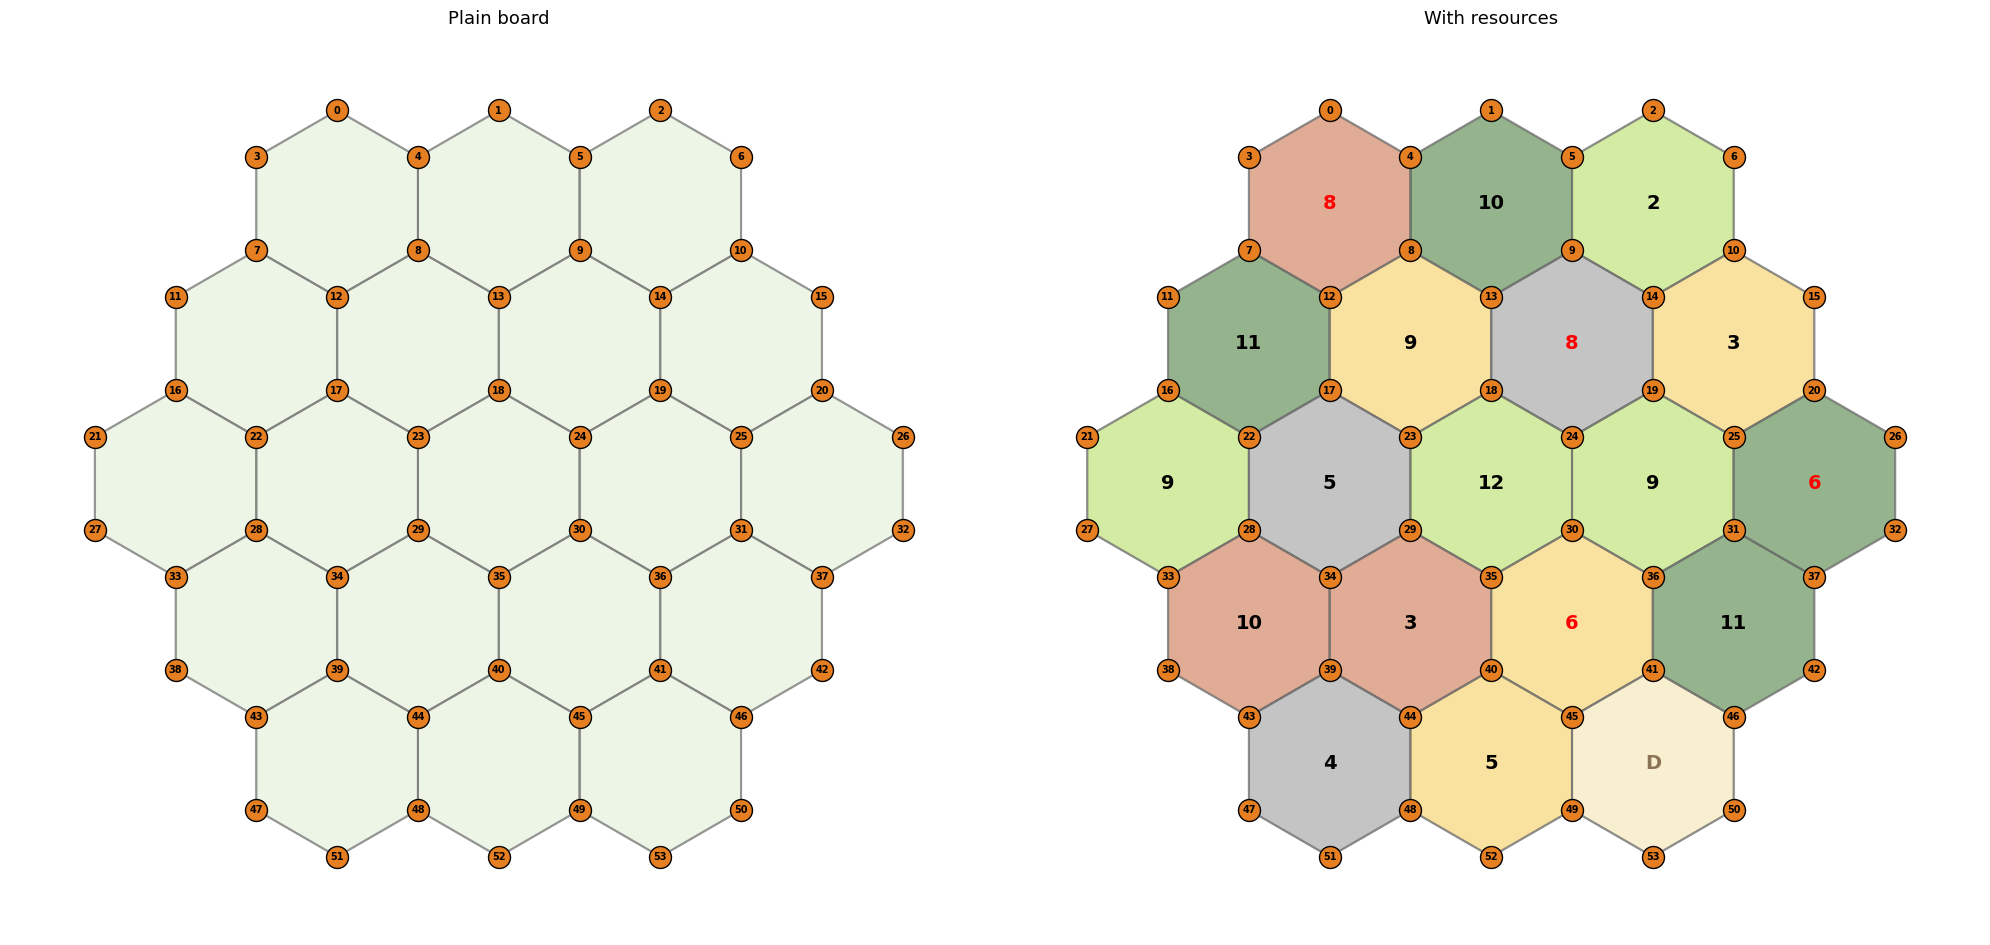

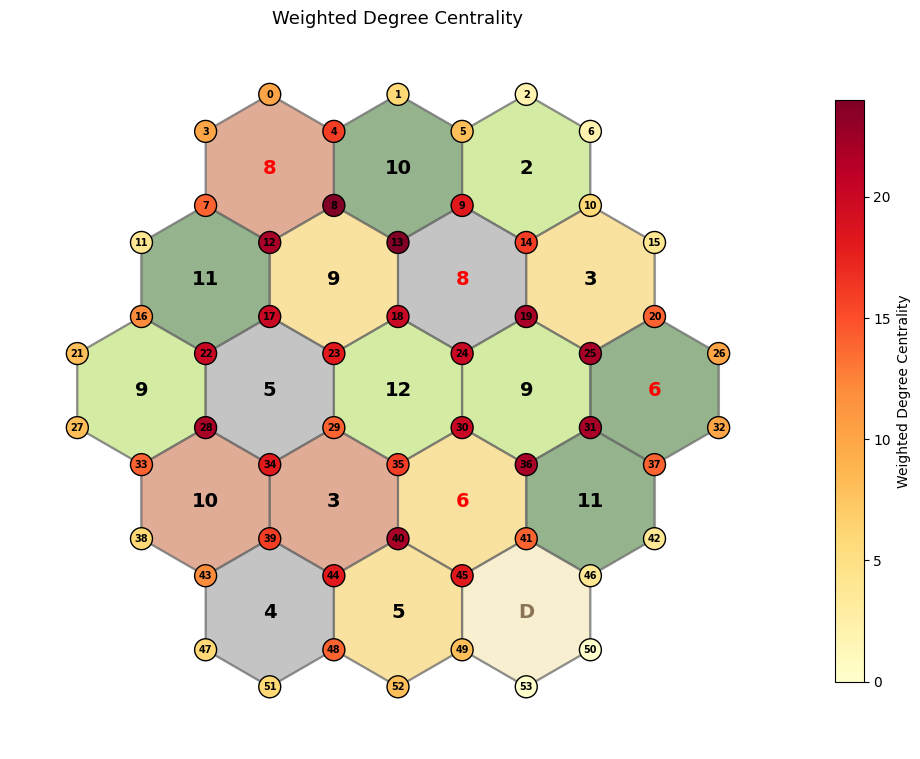

C:\Users\trunt\AppData\Local\Temp\ipykernel_21440\3770749138.py:189: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


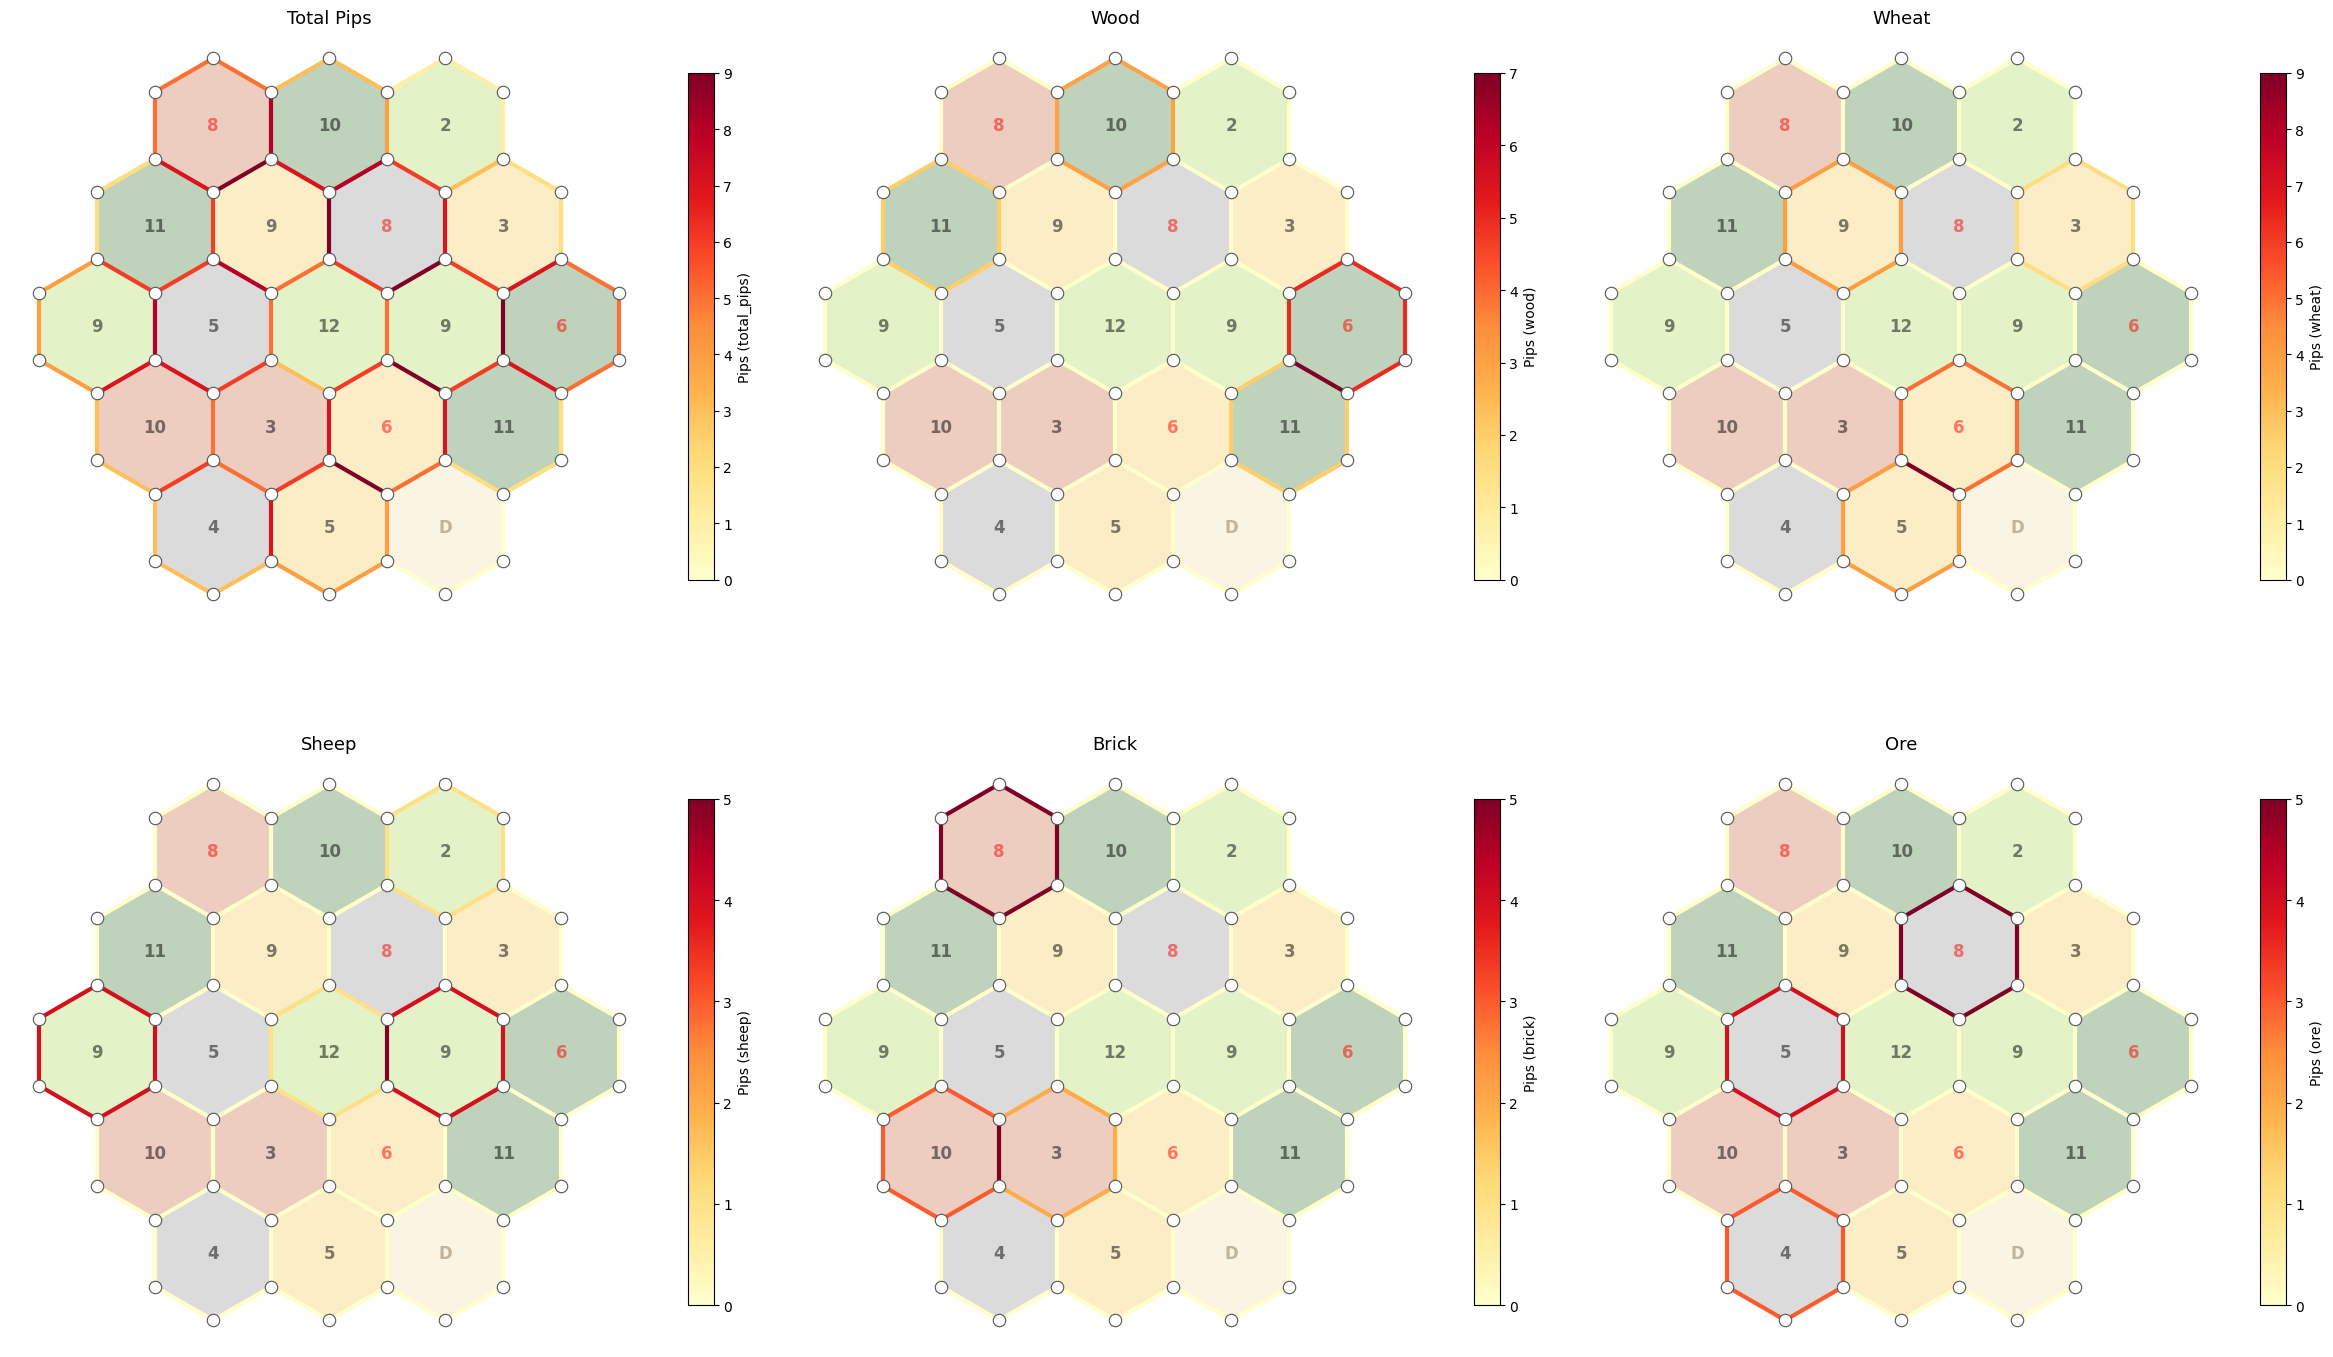

In [10]:
# ============================================================================
# Demo
# ============================================================================
# Basic Generation/Visualization
G, hex_centers = generate_catan_board()
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Example board layout (tiles in reading order, matching a real game).
# Each entry is (resource_type, number_token). Desert gets number 0.
example_tiles = [
    ('brick',  8), ('wood',  10), ('sheep',  2),                         # row 0
    ('wood',  11), ('wheat',  9), ('ore',     8), ('wheat', 3),          # row 1
    ('sheep',  9), ('ore',    5), ('sheep', 12), ('sheep', 9), ('wood', 6),  # row 2
    ('brick', 10), ('brick',  3), ('wheat',  6), ('wood', 11),           # row 3
    ('ore',    4), ('wheat',  5), ('desert',  0),                         # row 4
]
G = compute_edge_resources(G, example_tiles)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
draw_board(G, hex_centers, title="Plain board", ax=ax1)
draw_board(G, hex_centers, tile_data=example_tiles, title="With resources", ax=ax2)
plt.tight_layout()
plt.show()

# Weighted Degree Centrality (node coloring with colorbar)
weighted_deg_c = dict(G.degree(weight='total_pips'))
c_colors = [x for x in weighted_deg_c.values()]
draw_board(G, hex_centers, node_colors=c_colors, title="Weighted Degree Centrality", tile_data=example_tiles)
plt.tight_layout()
plt.show()

# Edge resource visualizations — total pips + per-resource breakdown
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
draw_edge_resources(G, hex_centers, example_tiles, resource=None, title="Total Pips", ax=axes[0, 0])
for i, res in enumerate(RESOURCES):
    row, col = divmod(i + 1, 3)
    draw_edge_resources(G, hex_centers, example_tiles, resource=res, title=res.capitalize(), ax=axes[row, col])
plt.tight_layout()
plt.show()

# NOTE! most centrality measures in NetworkX look something like nx.degree_centrality(G), look in the documentation on how to compute them and pay attention to the weight/distance parameter
# NOTE! you can do: Gw = resource_graph(G, 'ore') -- to extract a network where the edges only have the resource parameter of the specified resource.
#       Note that this method also has the reciprocal parameter that lets you do 1/resource - think about which centrality measures might benefit from this
